# Imports and Setup

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

print("All imports successful")
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))

All imports successful
TensorFlow version: 2.16.2
Num GPUs Available: 1
Num CPUs Available: 1


In [3]:
print("TensorFlow version:", tf.__version__)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

print("Num CPUs Available:", len(tf.config.list_physical_devices('CPU')))

TensorFlow version: 2.16.2
Num GPUs Available: 1
Num CPUs Available: 1


# Mulitmodal Classifier

## Data Loading and Initial Setup

In [4]:
df = pd.read_csv("data/metadata")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [5]:
image_dir = "data/images"

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,data/images/ISIC_0031633.jpg


In [6]:
print("Missing images:", df["image_path"].apply(lambda x: not os.path.exists(x)).sum())

Missing images: 0


In [7]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'dataset', 'image_path'],
      dtype='object')

In [8]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

## Data Cleaning and Preprocessing

In [9]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
image_path       0
dtype: int64

In [10]:
df["age"] = df["age"].fillna(df["age"].median())

df["sex"] = df["sex"].fillna("unknown")

df["localization"] = df["localization"].fillna("unknown")

In [11]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [12]:
df = pd.get_dummies(df, columns=["sex", "localization"])

In [13]:
y = df["label"]

X_meta = df.drop(columns=[
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "dataset",
    "image_path",
    "label"
])

In [14]:
df.head()

,lesion_id,image_id,dx,dx_type,age,dataset,image_path,label,sex_female,sex_male,...,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,vidir_modern,data/images/ISIC_0027419.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,vidir_modern,data/images/ISIC_0025030.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,vidir_modern,data/images/ISIC_0026769.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,vidir_modern,data/images/ISIC_0025661.jpg,2,False,True,...,False,False,False,False,False,False,True,False,False,False
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,vidir_modern,data/images/ISIC_0031633.jpg,2,False,True,...,False,False,False,False,False,False,False,False,False,False


In [15]:
for i, class_name in enumerate(le.classes_):
    print(i, ":", class_name)

0 : akiec
1 : bcc
2 : bkl
3 : df
4 : mel
5 : nv
6 : vasc


## Stratified K-Fold Cross-Validation

In [16]:
y = df["label"]
X_images = df["image_path"]

X_meta = df.drop(columns=[
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "dataset",
    "image_path",
    "label"
])

print("Metadata shape:", X_meta.shape)
print("Images:", X_images.shape)
print("Labels:", y.shape)

Metadata shape: (10015, 19)
Images: (10015,)
Labels: (10015,)


In [17]:
bool_cols = X_meta.select_dtypes(include=["bool"]).columns
X_meta[bool_cols] = X_meta[bool_cols].astype(int)

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y), start=1):
    fold_data = {
        "fold": fold,
        "X_meta_train": X_meta.iloc[train_idx].reset_index(drop=True),
        "X_meta_val": X_meta.iloc[val_idx].reset_index(drop=True),
        "X_img_train": X_images.iloc[train_idx].reset_index(drop=True),
        "X_img_val": X_images.iloc[val_idx].reset_index(drop=True),
        "y_train": y.iloc[train_idx].reset_index(drop=True),
        "y_val": y.iloc[val_idx].reset_index(drop=True)
    }
    folds.append(fold_data)
print("Number of folds saved:", len(folds))

Number of folds saved: 5


## Image Preprocessing and Feature Extraction

In [20]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("Model loaded")

/var/folders/fj/jj9hkmp960q3_hshpdf9t6jc0000gn/T/ipykernel_28753/2547163451.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
2026-04-04 19:13:17.893291: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-04 19:13:17.893338: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-04 19:13:17.893347: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-04 19:13:17.893649: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-04 19:13:17.893666: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0

Model loaded


In [21]:
def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    features = base_model.predict(img_array, verbose=0)
    return features[0]

### Feature Extraction Check

In [22]:
test_img = folds[0]["X_img_train"].iloc[0]

features = extract_features(test_img)

print("Feature shape:", features.shape)

2026-04-04 19:13:21.400284: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-04 19:13:21.476135: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Feature shape: (1280,)


### Batch Feature Extraction Functions

In [23]:
def load_and_preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    return preprocess_input(img_array)

def extract_features_batch(image_paths, batch_size=32):
    all_features = []
    
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.array([load_and_preprocess_image(p) for p in batch_paths])
        
        batch_features = base_model.predict(batch_images, verbose=0)
        all_features.append(batch_features)
        
        print(f"Processed {min(start + batch_size, len(image_paths))} / {len(image_paths)}")
    
    return np.vstack(all_features)

### Batch Extraction Test

In [24]:
sample_paths = folds[0]["X_img_train"].iloc[:64].tolist()
sample_features = extract_features_batch(sample_paths, batch_size=16)

print("Sample feature matrix shape:", sample_features.shape)

Processed 16 / 64
Processed 32 / 64
Processed 48 / 64
Processed 64 / 64
Sample feature matrix shape: (64, 1280)


## Train/Validation

In [25]:
X_img_train_fold1 = folds[0]["X_img_train"].tolist()
X_img_val_fold1 = folds[0]["X_img_val"].tolist()

X_train_img_features = extract_features_batch(X_img_train_fold1, batch_size=16)
X_val_img_features = extract_features_batch(X_img_val_fold1, batch_size=16)

print("Train image features shape:", X_train_img_features.shape)
print("Val image features shape:", X_val_img_features.shape)

Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Processed 736 / 8012
Processed 752 / 8012
Processed 768 / 801

In [26]:
X_train_meta = folds[0]["X_meta_train"].to_numpy(dtype=np.float32)
X_val_meta = folds[0]["X_meta_val"].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_val_meta_scaled = scaler.transform(X_val_meta)

print("Train metadata shape:", X_train_meta_scaled.shape)
print("Val metadata shape:", X_val_meta_scaled.shape)

Train metadata shape: (8012, 19)
Val metadata shape: (2003, 19)


## Combining Image Features and Metadata

In [27]:
X_train_combined = np.concatenate([X_train_img_features, X_train_meta_scaled], axis=1)
X_val_combined = np.concatenate([X_val_img_features, X_val_meta_scaled], axis=1)

print("Combined train shape:", X_train_combined.shape)
print("Combined val shape:", X_val_combined.shape)

Combined train shape: (8012, 1299)
Combined val shape: (2003, 1299)


## Class Weights

In [28]:
classes = np.unique(folds[0]["y_train"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=folds[0]["y_train"]
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}


## Multimodal Classifier Training

In [29]:
class_names = le.classes_
num_classes = len(class_names)

classifier = keras.Sequential([
    keras.Input(shape=(X_train_combined.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = classifier.fit(
    X_train_combined,
    folds[0]["y_train"].to_numpy(),
    validation_data=(X_val_combined, folds[0]["y_val"].to_numpy()),
    epochs=50,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/50


2026-04-04 19:17:12.052158: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4144 - loss: 1.5704 - val_accuracy: 0.5547 - val_loss: 1.2086
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5446 - loss: 1.1722 - val_accuracy: 0.5871 - val_loss: 1.0990
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5897 - loss: 1.0191 - val_accuracy: 0.6206 - val_loss: 0.9703
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6221 - loss: 0.9160 - val_accuracy: 0.6440 - val_loss: 0.9627
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6365 - loss: 0.8493 - val_accuracy: 0.6895 - val_loss: 0.8640
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6578 - loss: 0.7790 - val_accuracy: 0.7209 - val_loss: 0.7357
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6782 - loss: 0.7068 - val_accuracy: 0.7179 - val_loss: 0.7626
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6951 - loss: 0.6593 - val_accuracy: 0.7264

## Model Evaluation

In [30]:
label_map = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesion"
}

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


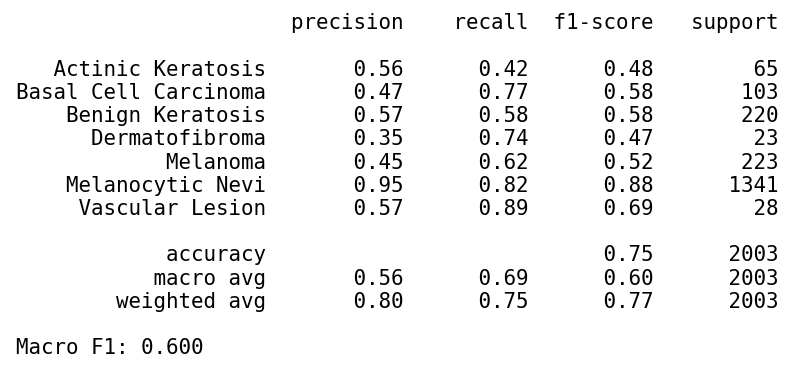

In [31]:
y_pred = classifier.predict(X_val_combined)
y_pred_classes = np.argmax(y_pred, axis=1)

report = classification_report(
    folds[0]["y_val"],
    y_pred_classes,
    target_names=[label_map[name] for name in class_names]
)
macro_f1 = f1_score(folds[0]["y_val"], y_pred_classes, average="macro")

report_with_macro = report + f"\nMacro F1: {macro_f1:.3f}"
plt.figure(figsize=(8, 4.5))
plt.text(0.01, 0.99, report_with_macro, fontsize=15, family="monospace", va="top")
plt.axis("off")
plt.savefig("outputs/classification_reports/multimodal_classification_report.png", bbox_inches="tight", pad_inches=0.2)
plt.show()

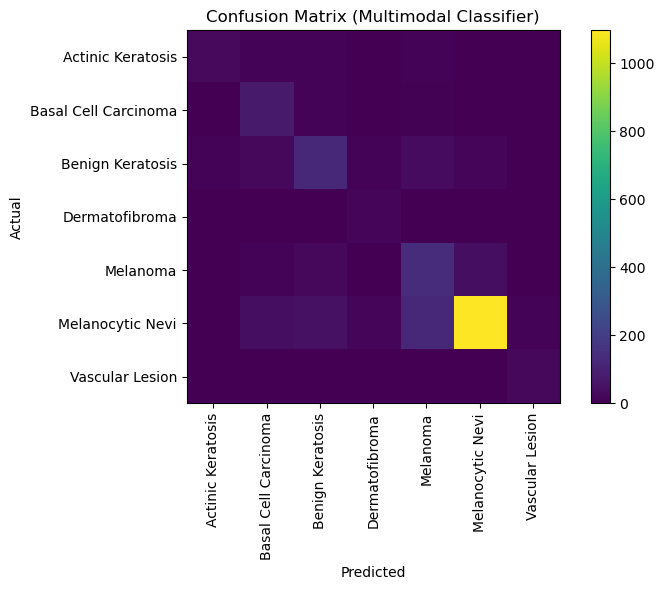

In [32]:
cm = confusion_matrix(folds[0]["y_val"], y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (Multimodal Classifier)")
plt.colorbar()
plt.xticks(range(len(class_names)), [label_map[c] for c in class_names], rotation=90)
plt.yticks(range(len(class_names)), [label_map[c] for c in class_names])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices/multimodal_confusion_matrix.png", bbox_inches="tight")
plt.show()

# Image-Only Classifier

## Data Loading and Initial Set Up

In [33]:
df = pd.read_csv("data/metadata")
image_dir = "data/images"

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,data/images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,data/images/ISIC_0031633.jpg


In [34]:
print("Missing images:", df["image_path"].apply(lambda x: not os.path.exists(x)).sum())

Missing images: 0


In [35]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

## Data Cleaning and Preprocessing

In [36]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

y = df["label"]
X_images = df["image_path"]

## Stratified K-Fold Cross-Validation

In [37]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_images, y), start=1):
    fold_data = {
        "fold": fold,
        "X_img_train": X_images.iloc[train_idx].reset_index(drop=True),
        "X_img_val": X_images.iloc[val_idx].reset_index(drop=True),
        "y_train": y.iloc[train_idx].reset_index(drop=True),
        "y_val": y.iloc[val_idx].reset_index(drop=True)
    }
    folds.append(fold_data)
print("Number of folds saved:", len(folds))

Number of folds saved: 5


# Train/Validation

In [39]:
X_img_train_fold1 = folds[0]["X_img_train"].tolist()
X_img_val_fold1 = folds[0]["X_img_val"].tolist()

X_train_img_features = extract_features_batch(X_img_train_fold1, batch_size=16)
X_val_img_features = extract_features_batch(X_img_val_fold1, batch_size=16)

print("Train image features shape:", X_train_img_features.shape)
print("Val image features shape:", X_val_img_features.shape)

Processed 16 / 8012
Processed 32 / 8012
Processed 48 / 8012
Processed 64 / 8012
Processed 80 / 8012
Processed 96 / 8012
Processed 112 / 8012
Processed 128 / 8012
Processed 144 / 8012
Processed 160 / 8012
Processed 176 / 8012
Processed 192 / 8012
Processed 208 / 8012
Processed 224 / 8012
Processed 240 / 8012
Processed 256 / 8012
Processed 272 / 8012
Processed 288 / 8012
Processed 304 / 8012
Processed 320 / 8012
Processed 336 / 8012
Processed 352 / 8012
Processed 368 / 8012
Processed 384 / 8012
Processed 400 / 8012
Processed 416 / 8012
Processed 432 / 8012
Processed 448 / 8012
Processed 464 / 8012
Processed 480 / 8012
Processed 496 / 8012
Processed 512 / 8012
Processed 528 / 8012
Processed 544 / 8012
Processed 560 / 8012
Processed 576 / 8012
Processed 592 / 8012
Processed 608 / 8012
Processed 624 / 8012
Processed 640 / 8012
Processed 656 / 8012
Processed 672 / 8012
Processed 688 / 8012
Processed 704 / 8012
Processed 720 / 8012
Processed 736 / 8012
Processed 752 / 8012
Processed 768 / 801

## Class Weights

In [40]:
classes = np.unique(folds[0]["y_train"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=folds[0]["y_train"]
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}


## Image-Only Classifier Training

In [41]:
class_names = le.classes_
num_classes = len(class_names)

classifier = keras.Sequential([
    keras.Input(shape=(X_train_img_features.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = classifier.fit(
    X_train_img_features,
    folds[0]["y_train"].to_numpy(),
    validation_data=(X_val_img_features, folds[0]["y_val"].to_numpy()),
    epochs=50,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/50


2026-04-04 19:21:28.368497: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4401 - loss: 1.5532 - val_accuracy: 0.5087 - val_loss: 1.3662
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5230 - loss: 1.2634 - val_accuracy: 0.4958 - val_loss: 1.3017
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5540 - loss: 1.0969 - val_accuracy: 0.6545 - val_loss: 0.9243
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5877 - loss: 1.0123 - val_accuracy: 0.6216 - val_loss: 1.0111
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6017 - loss: 0.9532 - val_accuracy: 0.6480 - val_loss: 0.9155
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6312 - loss: 0.8602 - val_accuracy: 0.6171 - val_loss: 0.9608
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6402 - loss: 0.8228 - val_accuracy: 0.6995 - val_loss: 0.7983
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6454 - loss: 0.7805 - val_accuracy: 0.668

## Model Evaluation

In [42]:
label_map = {
    "akiec": "Actinic Keratosis",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesion"
}

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


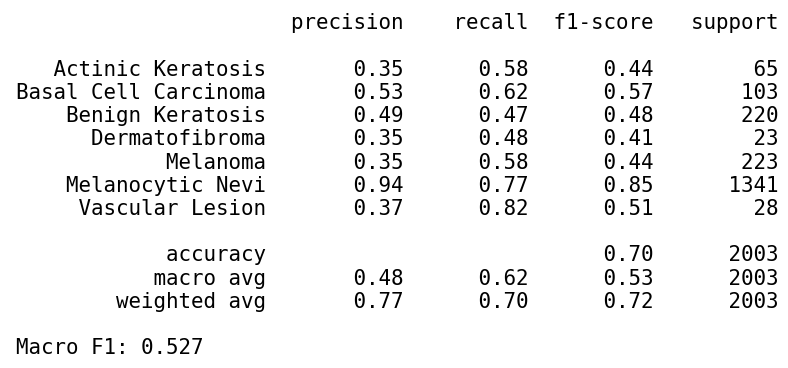

In [43]:
class_names = le.classes_

y_pred = classifier.predict(X_val_img_features)
y_pred_classes = np.argmax(y_pred, axis=1)

report = classification_report(
    folds[0]["y_val"],
    y_pred_classes,
    target_names=[label_map[name] for name in class_names]
)

macro_f1 = f1_score(folds[0]["y_val"], y_pred_classes, average="macro")
report_with_macro = report + f"\nMacro F1: {macro_f1:.3f}"

plt.figure(figsize=(8, 4.5))
plt.text(0.01, 0.99, report_with_macro, fontsize=15, family="monospace", va="top")
plt.axis("off")
plt.savefig(
    "outputs/classification_reports/image_only_classification_report.png",
    bbox_inches="tight",
    pad_inches=0.2
)
plt.show()

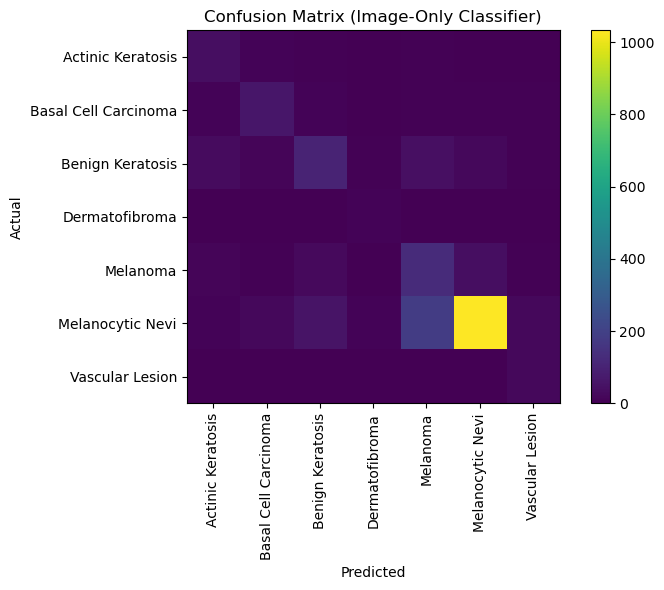

In [44]:
cm = confusion_matrix(folds[0]["y_val"], y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (Image-Only Classifier)")
plt.colorbar()
plt.xticks(range(len(class_names)), [label_map[name] for name in class_names], rotation=90)
plt.yticks(range(len(class_names)), [label_map[name] for name in class_names])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(
    "outputs/confusion_matrices/image_only_confusion_matrix.png",
    bbox_inches="tight"
)
plt.show()